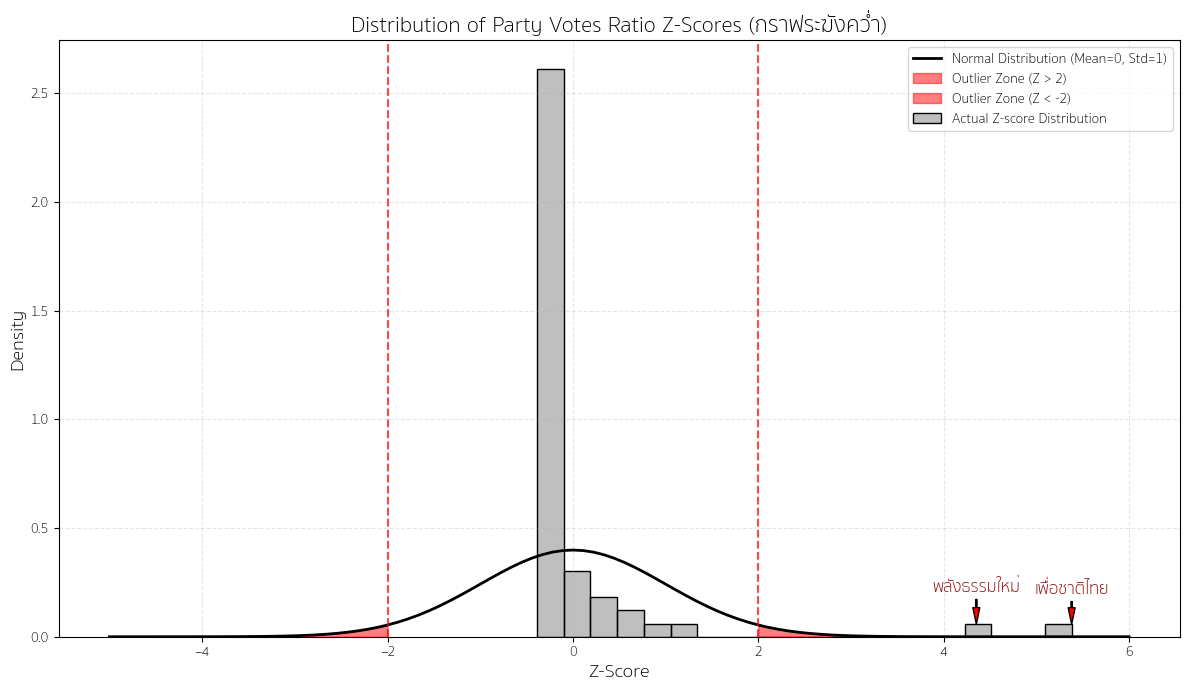

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import matplotlib as mpl
# --- FIX THAI FONT FOR MAC/WINDOWS ---
mpl.rcParams['font.family'] = ['Sukhumvit Set', 'Thonburi', 'Tahoma', 'sans-serif']
# -------------------------------------


# Load data
df = pd.read_csv('data/ins-2/merged_parties_with_ratio.csv')

# Drop any NaN z-scores just in case
z_scores = df['z_score'].dropna()

plt.figure(figsize=(12, 7))

# 1. Plot the histogram of Z-scores
sns.histplot(z_scores, bins=20, stat='density', color='gray', alpha=0.5, label='Actual Z-score Distribution')

# 2. Plot the standard normal distribution curve (Bell Curve)
xmin, xmax = plt.xlim()
x = np.linspace(min(xmin, -5), max(xmax, 6), 100)
p = norm.pdf(x, 0, 1)
plt.plot(x, p, 'k', linewidth=2, label='Normal Distribution (Mean=0, Std=1)')

# 3. Highlight the tails (|Z| > 2)
x_tail_right = np.linspace(2, max(x), 50)
p_tail_right = norm.pdf(x_tail_right, 0, 1)
plt.fill_between(x_tail_right, p_tail_right, color='red', alpha=0.5, label='Outlier Zone (Z > 2)')

x_tail_left = np.linspace(min(x), -2, 50)
p_tail_left = norm.pdf(x_tail_left, 0, 1)
plt.fill_between(x_tail_left, p_tail_left, color='red', alpha=0.5, label='Outlier Zone (Z < -2)')

# Annotate specific outlier parties
outliers = df[df['is_outlier'] == True]
for _, row in outliers.iterrows():
    plt.annotate(row['party_name'].split('-')[-1], 
                 xy=(row['z_score'], 0.05), 
                 xytext=(row['z_score'], 0.15 + np.random.uniform(0, 0.1)),
                 arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
                 fontsize=12, color='darkred', ha='center')

plt.title('Distribution of Party Votes Ratio Z-Scores (กราฟระฆังคว่ำ)', fontsize=16)
plt.xlabel('Z-Score', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.axvline(2, color='red', linestyle='--', alpha=0.7)
plt.axvline(-2, color='red', linestyle='--', alpha=0.7)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig('zscore_bell_curve.png', dpi=300)
plt.show()
